# Day 11: KMeans Clustering on Employee Embeddings
Goals:
1. Find natural skill clusters in our employee pool
2. Pick best k using Elbow Method + Silhouette Score
3. Visualise clusters with PCA (2D)

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

BASE = Path("../data/processed")

embeddings  = np.load(BASE / "employee_embeddings.npy")
emp_df      = pd.read_csv(BASE / "employees_with_index.csv", index_col=0)

print(f"Embeddings: {embeddings.shape}")
print(f"Employees : {len(emp_df)}")

Embeddings: (80, 384)
Employees : 80


## 1. Elbow Method — Finding the Best k

In [2]:
inertias    = []
sil_scores  = []
K_range     = range(2, 15)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(embeddings, labels))
    print(f"  k={k:2d}  inertia={km.inertia_:8.1f}  silhouette={sil_scores[-1]:.4f}")

best_k = K_range.start + np.argmax(sil_scores)
print(f"\n Best k by silhouette score: {best_k}")

  k= 2  inertia=    18.9  silhouette=0.2765
  k= 3  inertia=    16.4  silhouette=0.2750
  k= 4  inertia=    13.4  silhouette=0.3026
  k= 5  inertia=    11.4  silhouette=0.3060
  k= 6  inertia=     9.1  silhouette=0.3518
  k= 7  inertia=     7.9  silhouette=0.3771
  k= 8  inertia=     6.9  silhouette=0.3721
  k= 9  inertia=     6.5  silhouette=0.3647
  k=10  inertia=     6.2  silhouette=0.3657
  k=11  inertia=     5.8  silhouette=0.3343
  k=12  inertia=     5.7  silhouette=0.2782
  k=13  inertia=     5.4  silhouette=0.2961
  k=14  inertia=     5.2  silhouette=0.2794

 Best k by silhouette score: 7


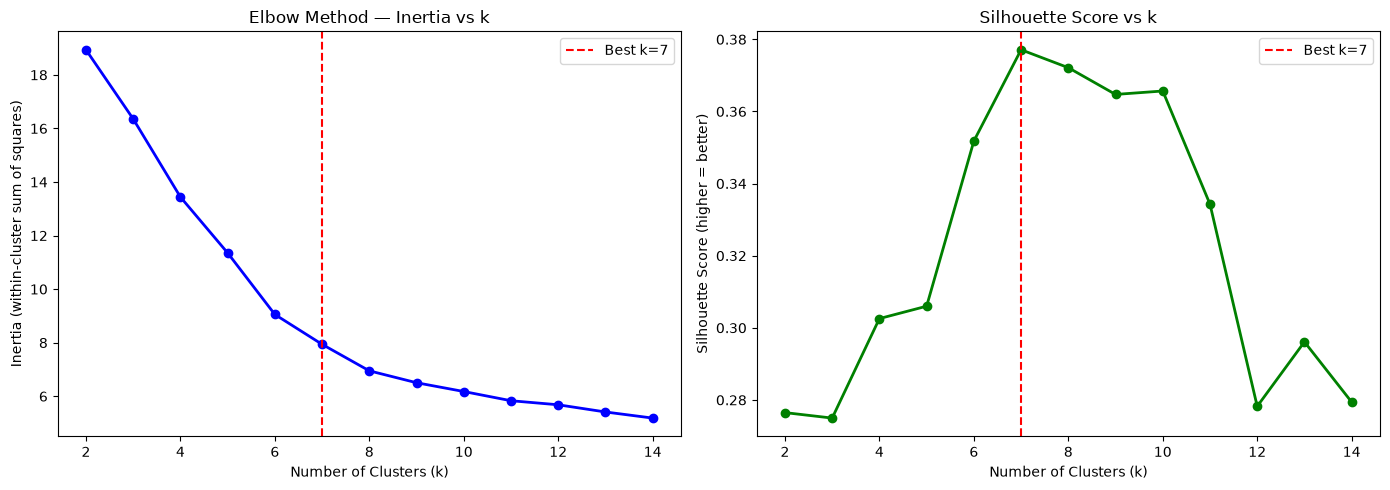

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_range), inertias, "bo-", linewidth=2, markersize=6)
axes[0].set_title("Elbow Method — Inertia vs k", fontsize=12)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[0].axvline(x=best_k, color="red", linestyle="--",
                label=f"Best k={best_k}")
axes[0].legend()

# Silhouette
axes[1].plot(list(K_range), sil_scores, "go-", linewidth=2, markersize=6)
axes[1].set_title("Silhouette Score vs k", fontsize=12)
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score (higher = better)")
axes[1].axvline(x=best_k, color="red", linestyle="--",
                label=f"Best k={best_k}")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/day11_elbow_silhouette.png", dpi=150)
plt.show()

## 2. Fit Final KMeans with Best k

In [4]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
emp_df["cluster"] = km_final.fit_predict(embeddings)

print("Employees per cluster:")
print(emp_df["cluster"].value_counts().sort_index().to_string())
print("\nRole distribution per cluster:")
print(emp_df.groupby("cluster")["role"].value_counts().to_string())

Employees per cluster:
cluster
0    16
1    10
2    11
3    20
4     5
5     9
6     9

Role distribution per cluster:
cluster  role           
0        Backend Dev        16
1        ML Engineer        10
2        Full Stack Dev     11
3        Data Engineer      12
         Data Scientist      7
         Project Manager     1
4        Android Dev         5
5        DevOps              9
6        Frontend Dev        9


## 3. PCA Visualization — 384D → 2D

Variance explained: 43.2%


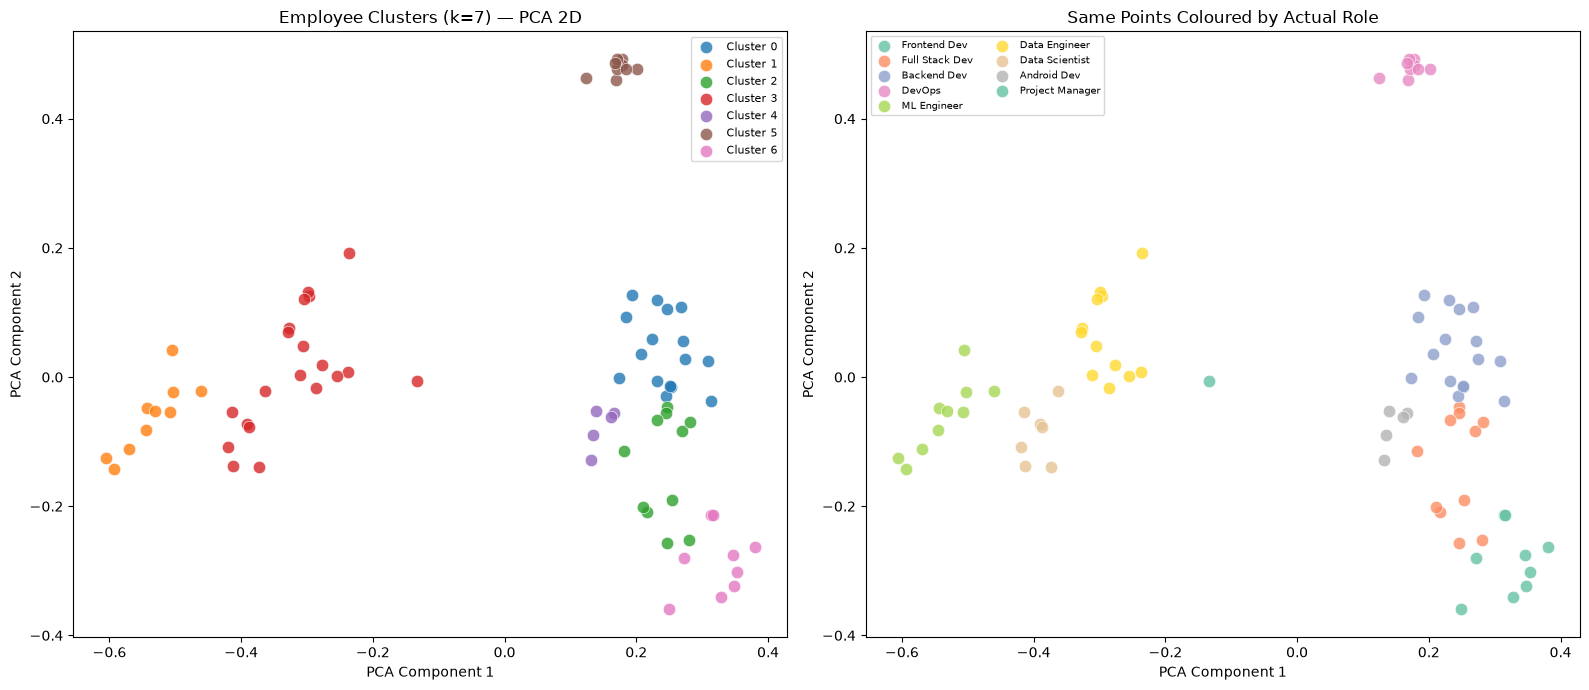

In [5]:
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

emp_df["pca_x"] = coords[:, 0]
emp_df["pca_y"] = coords[:, 1]

print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Colour by cluster
palette = sns.color_palette("tab10", n_colors=best_k)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot coloured by cluster
for c in range(best_k):
    mask = emp_df["cluster"] == c
    axes[0].scatter(
        emp_df.loc[mask, "pca_x"], emp_df.loc[mask, "pca_y"],
        color=palette[c], label=f"Cluster {c}",
        alpha=0.8, s=80, edgecolors="white", linewidths=0.5
    )
axes[0].set_title(f"Employee Clusters (k={best_k}) — PCA 2D", fontsize=12)
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
axes[0].legend(loc="best", fontsize=8)

# Plot coloured by role
roles   = emp_df["role"].unique()
rcolors = sns.color_palette("Set2", n_colors=len(roles))
for role, color in zip(roles, rcolors):
    mask = emp_df["role"] == role
    axes[1].scatter(
        emp_df.loc[mask, "pca_x"], emp_df.loc[mask, "pca_y"],
        color=color, label=role,
        alpha=0.8, s=80, edgecolors="white", linewidths=0.5
    )
axes[1].set_title("Same Points Coloured by Actual Role", fontsize=12)
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")
axes[1].legend(loc="best", fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig("../data/processed/day11_pca_clusters.png", dpi=150)
plt.show()

In [6]:
# Save cluster labels back to CSV for use in matcher
emp_df.to_csv(BASE / "employees_clustered.csv", index=True)
np.save(BASE / "cluster_labels.npy", emp_df["cluster"].values)
np.save(BASE / "cluster_centers.npy", km_final.cluster_centers_)
print(" Saved: employees_clustered.csv, cluster_labels.npy, cluster_centers.npy")

 Saved: employees_clustered.csv, cluster_labels.npy, cluster_centers.npy
